# Lab 4

We ran through parts of this notebook in class for Lecture 7 and Lecture 8. Now we will extend these analyses to look at our data in more detail and apply some of the 

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from matplotlib import pyplot as plt
import glob
import os

In [2]:
summary_df = pd.read_csv('Lab4_data/summary_df.csv')  
df_all = pd.read_csv('Lab4_data/df_all.csv')
df_bins = pd.read_csv('Lab4_data/df_bins.csv')
google_form = pd.read_csv('Lab4_data/google_form.csv')

In [3]:
# summary_df has one row per observation and shows the number of taps for that observation
summary_df

,Unnamed: 0,subj,hand,finger,handedness,dominant_hand,ntaps
0,0,0,left,index,left,True,330
1,1,1,right,pinky,right,True,371
2,2,2,left,pinky,right,False,296
3,3,3,left,index,right,False,308
4,4,4,right,index,left,False,301
...,...,...,...,...,...,...,...
96,96,96,left,pinky,right,False,314
97,97,97,left,index,left,True,355
98,98,98,left,index,right,False,305
99,99,99,right,index,right,True,387


In [4]:
# df_all has all of the data from everyone, including all the individual taps, as well
# as repeated metadata about the person ('subj') who completed the task
# For example, the first several rows are from subj 0, who is left handed and used 
# their left index finger for the first part of the task
df_all

,Unnamed: 0,tap_index,t_seconds,dt_seconds,subj,finger,hand,handedness,dominant_hand,time_bin
0,0,1,0.000,0.000,0,index,left,left,True,0
1,1,2,0.149,0.149,0,index,left,left,True,0
2,2,3,0.316,0.167,0,index,left,left,True,0
3,3,4,0.483,0.167,0,index,left,left,True,0
4,4,5,0.634,0.151,0,index,left,left,True,0
...,...,...,...,...,...,...,...,...,...,...
34108,34108,343,58.878,0.188,100,index,right,right,True,5
34109,34109,344,59.058,0.180,100,index,right,right,True,5
34110,34110,345,59.229,0.171,100,index,right,right,True,5
34111,34111,346,59.411,0.182,100,index,right,right,True,5


In [5]:
# df_bins is the binned data when we use 10 second bins -- this is very
# much an oversimplification of the trend over time, but for now
# is simple to look at
# For example, the first row is for subj 0, time_bin 0 corresponds to the
# first 10 seconds of their attempt, and they had 66 taps in that time bin.
# In the second 10 seconds, they had 54 taps.
df_bins 

,Unnamed: 0,subj,handedness,finger,hand,dominant_hand,time_bin,taps_bin
0,0,0,left,index,left,True,0,66
1,1,0,left,index,left,True,1,54
2,2,0,left,index,left,True,2,52
3,3,0,left,index,left,True,3,55
4,4,0,left,index,left,True,4,50
...,...,...,...,...,...,...,...,...
598,598,100,right,index,right,True,1,60
599,599,100,right,index,right,True,2,57
600,600,100,right,index,right,True,3,57
601,601,100,right,index,right,True,4,56


In [6]:
# google_form has additional data about whether they slept enough, whether
# they play video games more than 10 hrs a week, and how many years they
# played a sport. Remember this doesn't fully overlap with our other dataset
# and has a different number of rows, though we could try to match them up 
# later
google_form

,Unnamed: 0,ntaps,handedness,finger,hand,gamer,sleep_hrs,sport,dominant_hand
0,0,338,Right,Pinky,Left,No,7.00,0,False
1,1,398,Right,Index,Right,No,6.00,8,True
2,2,364,Right,Index,Right,No,5.00,0,True
3,3,409,Right,Pinky,Right,Yes,4.00,7,True
4,4,304,Right,Index,Left,No,5.83,2,False
...,...,...,...,...,...,...,...,...,...
60,60,360,Right,Index,Right,No,6.00,5,True
61,61,271,Left,Pinky,Right,No,6.00,4,False
62,62,425,Right,Index,Right,No,8.00,4,True
63,63,328,Right,Index,Left,No,8.50,7,False


# Using seaborn to explore our dataset

[Seaborn](https://seaborn.pydata.org/) is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics.

We'll use it to explore some of the features of our data

In [7]:
!pip install seaborn # Comment out if already installed
import seaborn as sns

<Axes: xlabel='tap_index', ylabel='t_seconds'>

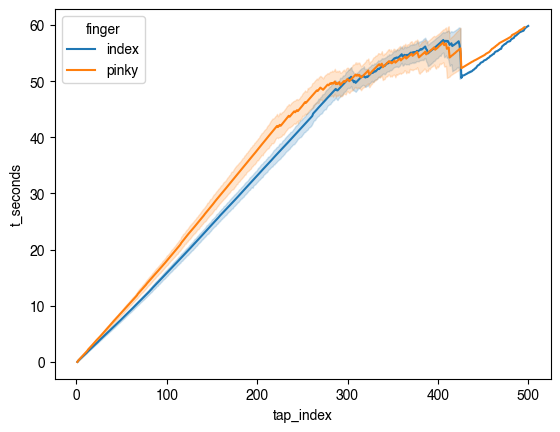

In [8]:
sns.lineplot(x='tap_index', y='t_seconds', hue='finger', data=df_all)

<Axes: xlabel='dominant_hand', ylabel='dt_seconds'>

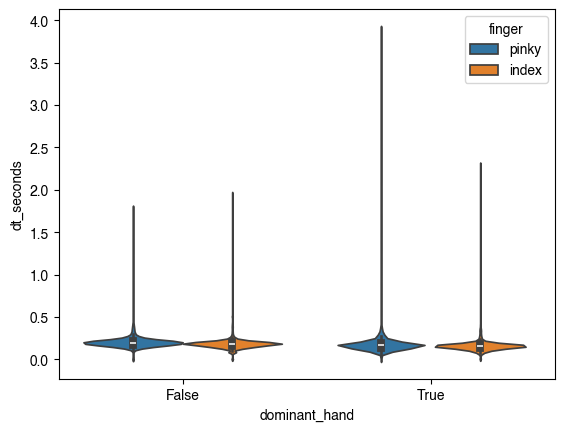

In [9]:
sns.violinplot(data=df_all, x='dominant_hand', y='dt_seconds', hue='finger')

In [10]:
summary_df

,Unnamed: 0,subj,hand,finger,handedness,dominant_hand,ntaps
0,0,0,left,index,left,True,330
1,1,1,right,pinky,right,True,371
2,2,2,left,pinky,right,False,296
3,3,3,left,index,right,False,308
4,4,4,right,index,left,False,301
...,...,...,...,...,...,...,...
96,96,96,left,pinky,right,False,314
97,97,97,left,index,left,True,355
98,98,98,left,index,right,False,305
99,99,99,right,index,right,True,387


# Fitting regression models

Now we're going to fit some simple linear regression models with OLS. This is not necessarily the best choice for these data, but more on that later. For now, we're interested in whether the number of taps that someone makes can be modeled as a function of whether they used their dominant hand and which finger they used:

$\text{ntaps} = \beta_0 + \beta_1 (\text{dominant hand}) + \beta_2 (\text{pinky finger})$

As we saw in class, we could use dummy coded variables to assign Left/Right and Pinky/Index to new columns of zeros and ones, but we can also use the statsmodels formulas to make this a little more intuitive, as follows:

In [11]:
import statsmodels.formula.api as smf

In [12]:
model = smf.ols(formula="ntaps~ C(dominant_hand) + C(finger)", data=summary_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  ntaps   R-squared:                       0.262
Model:                            OLS   Adj. R-squared:                  0.247
Method:                 Least Squares   F-statistic:                     17.38
Date:                Thu, 12 Feb 2026   Prob (F-statistic):           3.47e-07
Time:                        15:23:19   Log-Likelihood:                -531.87
No. Observations:                 101   AIC:                             1070.
Df Residuals:                      98   BIC:                             1078.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [13]:
# What if we just wanted to fit whether taps depend only on using dominant hand? Note
# the difference in Adj. R-squared compared to the last example.

# FILL IN

# Plots to look at balance within our data

Are we sampling evenly across handedness? Around 10-12% of the world's population is left-handed, so we should expect that to be roughly the case for the data we get here. Let's see if that pans out.

<Axes: xlabel='handedness', ylabel='count'>

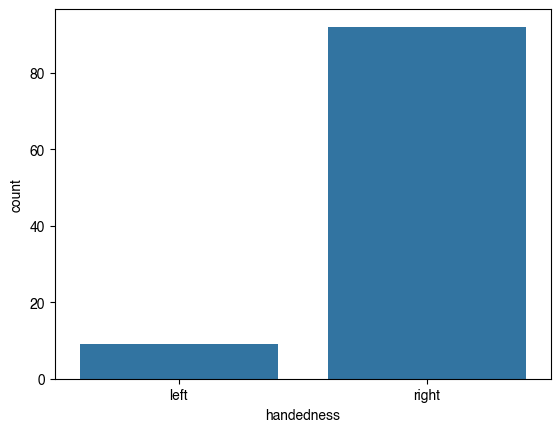

In [14]:
sns.countplot(x='handedness', data=summary_df)

We do indeed have an imbalance in the data, with many more right-handed people than left-handed people. If we ran a regression just looking at whether using your right hand helps, it would show that there is a strong positive effect, but this is drive by the fact that we are mostly running this on right-handed people! So remember to think about how to interpret your coefficients in the context of your actual data.

Let's also just plot which hand the person used to do the task, and whether it was their dominant hand:

<Axes: xlabel='hand', ylabel='count'>

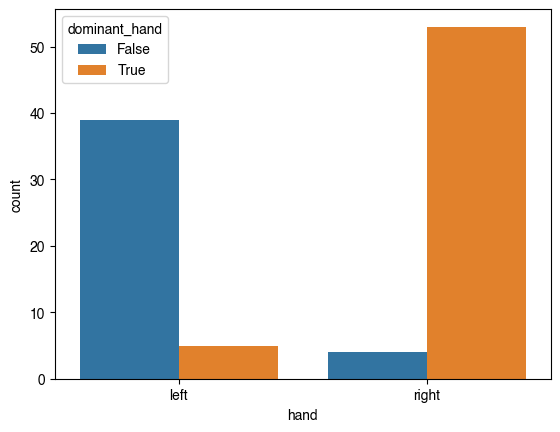

In [15]:
sns.countplot(x='hand', data=summary_df, hue='dominant_hand')

# Google form data

We also collected data from our google form on sports, gaming, and sleep. Let's look at that here:

In [16]:
google_form

,Unnamed: 0,ntaps,handedness,finger,hand,gamer,sleep_hrs,sport,dominant_hand
0,0,338,Right,Pinky,Left,No,7.00,0,False
1,1,398,Right,Index,Right,No,6.00,8,True
2,2,364,Right,Index,Right,No,5.00,0,True
3,3,409,Right,Pinky,Right,Yes,4.00,7,True
4,4,304,Right,Index,Left,No,5.83,2,False
...,...,...,...,...,...,...,...,...,...
60,60,360,Right,Index,Right,No,6.00,5,True
61,61,271,Left,Pinky,Right,No,6.00,4,False
62,62,425,Right,Index,Right,No,8.00,4,True
63,63,328,Right,Index,Left,No,8.50,7,False


# Investigate other model effects

Effect of playing sports and being a gamer are shown below:

In [17]:
model = smf.ols(formula = "ntaps ~ C(finger) + C(dominant_hand) + sport", data=google_form).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  ntaps   R-squared:                       0.308
Model:                            OLS   Adj. R-squared:                  0.274
Method:                 Least Squares   F-statistic:                     9.064
Date:                Thu, 12 Feb 2026   Prob (F-statistic):           4.75e-05
Time:                        15:23:19   Log-Likelihood:                -348.99
No. Observations:                  65   AIC:                             706.0
Df Residuals:                      61   BIC:                             714.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [18]:
model = smf.ols(formula = "ntaps ~ C(finger) + C(dominant_hand) + C(gamer)", data=google_form).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  ntaps   R-squared:                       0.384
Model:                            OLS   Adj. R-squared:                  0.354
Method:                 Least Squares   F-statistic:                     12.69
Date:                Thu, 12 Feb 2026   Prob (F-statistic):           1.51e-06
Time:                        15:23:19   Log-Likelihood:                -345.21
No. Observations:                  65   AIC:                             698.4
Df Residuals:                      61   BIC:                             707.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

<Axes: xlabel='dominant_hand', ylabel='ntaps'>

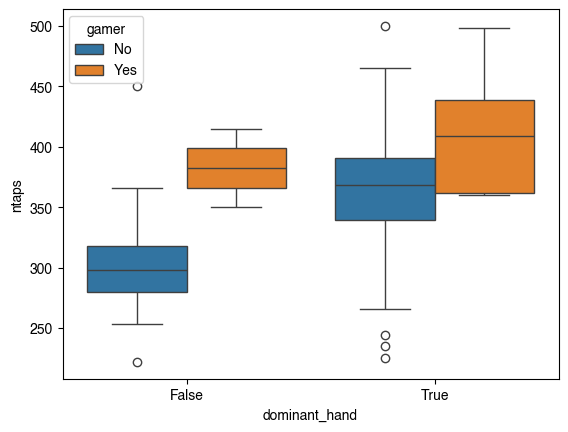

In [19]:
sns.boxplot(x='dominant_hand', y='ntaps', hue='gamer', data=google_form)

<Axes: xlabel='finger', ylabel='ntaps'>

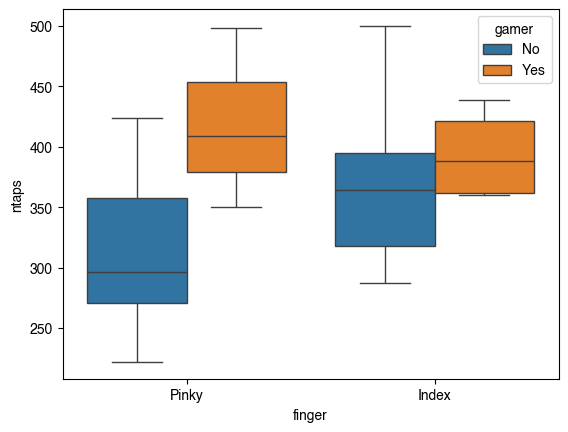

In [20]:
# can you make a boxplot showing whether using your pinky vs your index finger
# results in more taps for gamers vs. non gamers? Your data should be colored
# by gamer vs. nongamer.
sns.boxplot(x='finger', y='ntaps', hue='gamer', data=google_form)

<Axes: xlabel='gamer', ylabel='ntaps'>

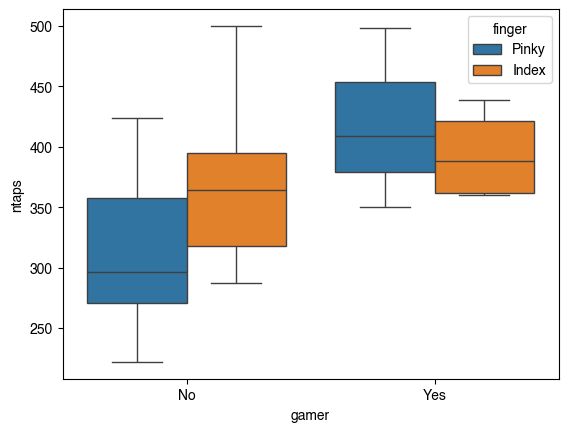

In [21]:
# Let's show the same data (ntaps) but change which is x and which is hue.
# (Let's make the finger the color this time)
# Does this make you interpret the data differently or think about it 
# differently? Do the two graphs make certain comparisons more obvious?
sns.boxplot(x='gamer', y='ntaps', hue='finger', data=google_form)

# Look at the data as a time series

What if we want to see how the number of taps changes over time? We can bin the data (though this can be dangerous... so do look at how binning data affects your results). We'll start here by binning our data in 10 second bins and looking at decay over time bins.

In [22]:
bin_size = 10 # in seconds -- you could also change this to something else!
df_all['time_bin'] = (df_all['t_seconds'] // bin_size).astype(int)
df_all

df_bins = ( df_all.groupby(['subj', 'handedness', 'finger','hand','dominant_hand', 'time_bin'])
            .size()
            .reset_index(name='taps_bin')
          )
df_bins

,subj,handedness,finger,hand,dominant_hand,time_bin,taps_bin
0,0,left,index,left,True,0,66
1,0,left,index,left,True,1,54
2,0,left,index,left,True,2,52
3,0,left,index,left,True,3,55
4,0,left,index,left,True,4,50
...,...,...,...,...,...,...,...
598,100,right,index,right,True,1,60
599,100,right,index,right,True,2,57
600,100,right,index,right,True,3,57
601,100,right,index,right,True,4,56


# Examples of how taps change as a function of time bin

Again let's do some exploration of the dataset, splitting by different categories.

<Axes: xlabel='time_bin', ylabel='taps_bin'>

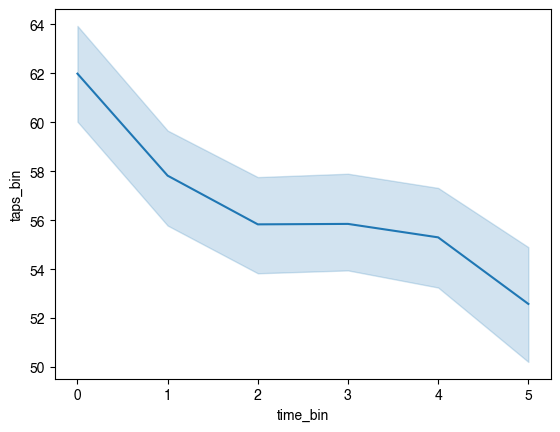

In [23]:
sns.lineplot(x='time_bin', y='taps_bin', data=df_bins)

<Axes: xlabel='time_bin', ylabel='taps_bin'>

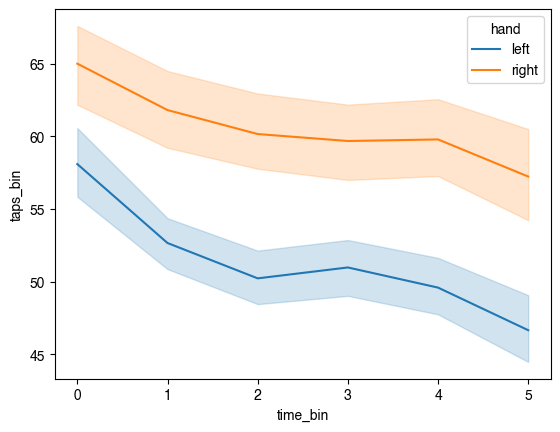

In [24]:
sns.lineplot(x='time_bin', y='taps_bin', hue='hand', data=df_bins)

<Axes: xlabel='time_bin', ylabel='taps_bin'>

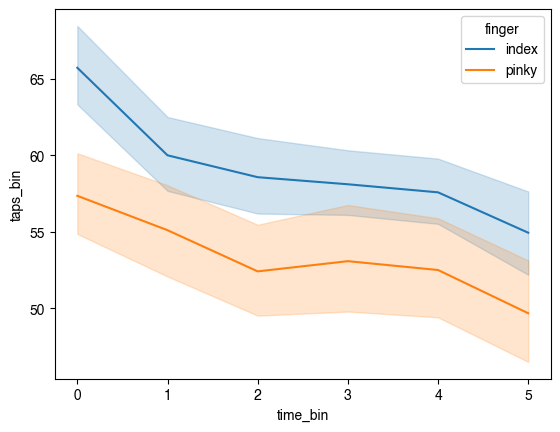

In [25]:
sns.lineplot(x='time_bin', y='taps_bin', hue='finger', data=df_bins)

# Fitting models

Now we can fit some models to see how the number of taps per bin varies as a function of the time bin and other covariates. Note the adjusted R-squared and other metrics. Are these good models? Why or why not?

In [26]:
model=smf.ols('taps_bin ~ time_bin', data=df_bins).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               taps_bin   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     39.96
Date:                Thu, 12 Feb 2026   Prob (F-statistic):           5.06e-10
Time:                        15:23:19   Log-Likelihood:                -2264.1
No. Observations:                 603   AIC:                             4532.
Df Residuals:                     601   BIC:                             4541.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     60.4624      0.746     81.047      0.0

In [27]:
model = smf.ols('taps_bin ~ time_bin*C(finger) + C(dominant_hand)', data=df_bins).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               taps_bin   R-squared:                       0.282
Model:                            OLS   Adj. R-squared:                  0.278
Method:                 Least Squares   F-statistic:                     58.82
Date:                Thu, 12 Feb 2026   Prob (F-statistic):           7.05e-42
Time:                        15:23:19   Log-Likelihood:                -2183.5
No. Observations:                 603   AIC:                             4377.
Df Residuals:                     598   BIC:                             4399.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

# Try the regressions again but using a different binning ... what do you notice?

In [28]:
# binning of 2 seconds, 5 seconds, something else?

# What assumptions are we making?

When we collected our data, we had each person tap twice, once with their pinky and once with their index finger, but using the same hand. Does this affect the validity of any of the assumptions we make with this analysis?

# Relating to other topics

* How do the data we've collected here relate to topics about autocovariance? (can you calculate the autocovariance of your own dataset by loading the csv?)
* How do you think this regression would look if we had people trying to do the finger tapping task for an even longer time? Is linear regression the best solution?